In [1]:
import numpy as np
import myutils.psfuncs.psestimation as pe
import matplotlib.pyplot as plt
plt.style.use('/home/cts23ph/SP_FINAL/mplstyle')

Imported myutils
Imported psfuncs,   Import Time : 01/06/26 | 04:17:41 PM


In [2]:
nuc  = 154.255 # observing frequency in MHz
dnuc = 0.04    # freq separation in MHz
NE   = 668     # no of channels used to estimate PS 

In [3]:
# ell values array
fname = '/home/cts23ph/git_package_myutils/tge/bin_info_1000007200.npz'
lval  = (np.load(fname)['lval']).astype('int')

### $\texttt{Extract Necessary Information}$

In [4]:
r, rp, fac, vfac, kper, kpara = pe.build_essential(nuc, dnuc, NE, lval)

--------------------------------------
Cosmological Model: Planck18
Redshift          : z  = 8.21
Comoving distance : r  = 9191.20 Mpc
rprime            : rp = 16.93 Mpc/MHz
Sep used          : NE = 668
--------------------------------------
Wedge boundary slope (fac) : 3.519          
DCT factor (vfac)          : 3.816e+10          
kper.shape                 : (20,)          
kpara.shape                : (668,)
--------------------------------------


In [5]:
r, rp, fac, vfac, kper, kpara = pe.build_essential(nuc, dnuc, NE, lval,
                                                     model = 'FlatLambdaCDM')

--------------------------------------
Cosmological Model: FlatLambdaCDM
Redshift          : z  = 8.21
Comoving distance : r  = 9209.37 Mpc
rprime            : rp = 16.99 Mpc/MHz
Sep used          : NE = 668
--------------------------------------
Wedge boundary slope (fac) : 3.514          
DCT factor (vfac)          : 3.844e+10          
kper.shape                 : (20,)          
kpara.shape                : (668,)
--------------------------------------


In [6]:
# kper  shape (len(lval),)
# kpara shape (NE,)

### $\texttt{Hermitian matrix}\,\mathbf{A}$

In [7]:
print(pe.calc_A(2,2))
print(np.round(pe.calc_A(3,3),3))
print(np.round(pe.calc_A(4,4),3))
print(np.round(pe.calc_A(2,4),3))

[[ 0.5  0.5]
 [ 0.5 -0.5]]
[[ 0.5  1.   0.5]
 [ 0.5  0.  -0.5]
 [ 0.5 -1.   0.5]]
[[ 0.5  1.   1.   0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5  0.5]
 [ 0.5 -1.   1.  -0.5]]
[[ 0.5  1.   1.   0.5]
 [ 0.5  0.5 -0.5 -0.5]]


### $\texttt{Blackman-Nuttal Window}\,\mathcal{W}_{\rm BN}(\Delta\nu_n)$

In [8]:
np.set_printoptions(precision = 4, suppress = True)
w = pe.window(N = 5) # Blackman Nutall window of length 5.
print(f"w = {w}")
w = pe.window(N = 7) # Blackman Nutall window of length 7.
print(f"w = {w}")

w = [1.     0.702  0.227  0.0252 0.0004]
w = [1.     0.8555 0.5292 0.227  0.0613 0.0082 0.0004]


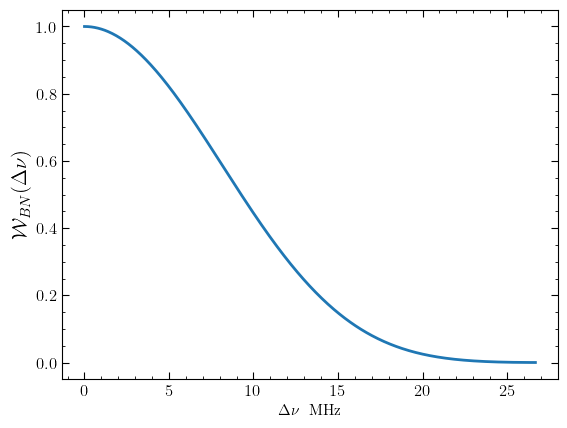

In [9]:
# plot the window function of length NE
plt.plot(dnuc*np.arange(NE), pe.window(NE))
plt.xlabel(r'$\Delta\nu\,\,\,\,{\rm MHz}$', fontsize = 11)
plt.ylabel(r'$\mathcal{W}_{BN}(\Delta\nu)$')

plt.savefig(f"window.pdf", dpi = 700, bbox_inches = "tight", pad_inches = 0.04)
plt.show()

### $\texttt{Power Spectrum Estimation}\,P(k_\perp,k_\parallel)$

In [10]:
index = 7200

In [11]:
cl   = np.load(f'/home/cts23ph/git_package_myutils/clfuncs/cldnur_{index}.npy')[...,:NE]
cln  = np.load(f'/home/cts23ph/git_package_myutils/clfuncs/cldnur_noise_{index}.npy')[...,:NE]

In [12]:
dcln = np.std(cln, axis = 0)
covi = 1/dcln**2

In [13]:
# window for Fourier transform
w    = pe.window(NE) 
# MLE cylindrical PS P(kper, kpara)
pk   = pe.func_pk(cl, w, covi, vfac)
print(f'{cl.shape        = }\
      \n{covi.shape      = }\
      \n{w.shape         = }\
      \n{pk.shape        = }')

cl.shape        = (20, 668)      
covi.shape      = (20, 668)      
w.shape         = (668,)      
pk.shape        = (20, 668)


In [14]:
from matplotlib.colors import LogNorm

In [15]:
# cylindraical PS
pmin = np.min(abs(pk))
pmax = np.max(abs(pk))
y, x = np.meshgrid(kpara+kpara[1], kper)

In [16]:
cmap = plt.cm.rainbow.copy()
cmap.set_bad(color = 'lightgray')

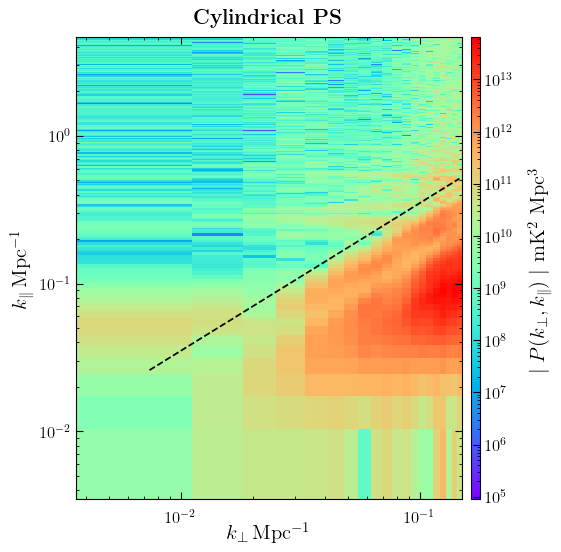

In [17]:
fig, axs = plt.subplots(figsize = (6, 6))

cax = axs.pcolormesh(x, y, abs(pk), norm = LogNorm(pmin, pmax), shading = 'auto', cmap = cmap, rasterized = True)

cbar = fig.colorbar(cax, ax = axs, pad = 0.02, aspect = 50, location='right')

axs.plot(kper, fac*kper, color = 'black', ls='--', lw = 1.25)
axs.set_xscale('log')
axs.set_yscale('log')
axs.tick_params(axis = 'x', which = 'major', pad = 8)

cbar.set_label(r'$\mid P(k_{\perp}, k_\parallel) \mid$ ${\rm mK^2}$ ${\rm Mpc^{3}}$', labelpad=10)
axs.set_xlabel(r'$k_{\perp}\,{\rm Mpc^{-1} }$', labelpad = -3)
    
axs.set_ylabel(r'$k_{\parallel}\,{\rm Mpc^{-1} }$')
plt.title(r'\bf Cylindrical PS', pad  = 10, fontsize = 15)

plt.savefig(f'cyl_ps_{index}.pdf', dpi = 700, bbox_inches = 'tight')

plt.show()

### $\texttt{Noise Power Spectrum }\,P_N(k_\perp,k_\parallel)$

In [18]:
# MLE cylindrical PS P(kper, kpara)       # noise
pkn   = pe.func_pk(cln, w, covi, vfac)    # noise ps
dpkn  = np.std(pkn, axis = 0)             # std noise of ps
dpkn *= (20)**2                           # scale the noise accordingly

In [19]:
#N_nights = 9  so its 20

$\texttt{Scale the noise with}\,\,\sigma_N = \dfrac{60}{\sqrt{N_{\rm nights}}}$

### $\texttt{flag mask array}$

In [20]:
flag_mask = np.zeros((kper.size,kpara.size), dtype = 'int')

print(flag_mask.shape)

ks  = np.array([0.135, 0.228, 0.36, 0.5, 0.72, 0.8, 0.92, 1.09, 1.17, 1.39])
ksv = np.array([0,0,1,2,2,2])

for ii in range(len(ksv)):
    for jj in range(ksv[ii],len(ksv)-1):
        mask = (kpara>=ks[2*jj])*(kpara<=ks[2*jj+1])
        flag_mask[ii,mask] = 1

np.save('flag_mask.npy',flag_mask)   # save the array

(20, 668)


In [21]:
fm = np.load('flag_mask.npy')        # flag_mask array

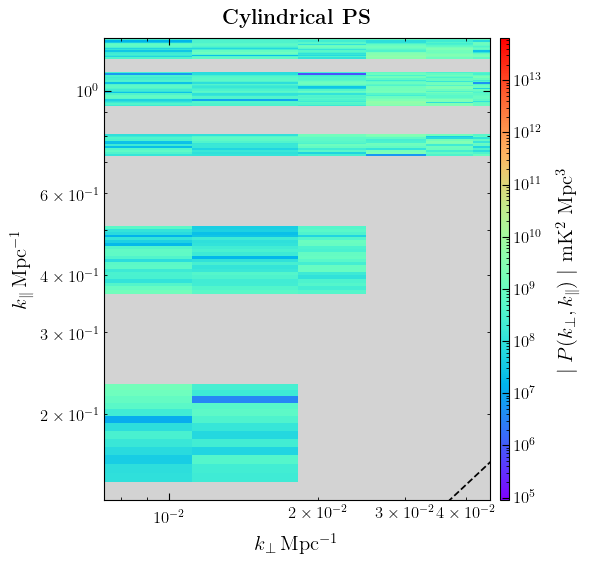

In [22]:
pk_masked = np.ma.masked_array(pk,mask = ~np.bool(np.ones_like(pk)*fm))

fig, axs = plt.subplots(figsize = (6, 6))

cax = axs.pcolormesh(x, y, abs(pk_masked), norm = LogNorm(pmin, pmax), shading = 'auto', cmap = cmap, rasterized = True)

cbar = fig.colorbar(cax, ax = axs, pad = 0.02, aspect = 50, location='right')

axs.plot(kper, fac*kper, color = 'black', ls='--', lw = 1.25)
axs.set_xscale('log')
axs.set_yscale('log')
axs.tick_params(axis = 'x', which = 'major', pad = 8)

cbar.set_label(r'$\mid P(k_{\perp}, k_\parallel) \mid$ ${\rm mK^2}$ ${\rm Mpc^{3}}$', labelpad=10)
axs.set_xlabel(r'$k_{\perp}\,{\rm Mpc^{-1} }$', labelpad=5 )
    
axs.set_ylabel(r'$k_{\parallel}\,{\rm Mpc^{-1} }$')
plt.title(r'\bf Cylindrical PS', pad  = 10, fontsize = 15)

axs.set_xlim([kper[0],kper[5]])
axs.set_ylim([0.13,1.3])

plt.savefig(f'cyl_ps_masked_{index}.pdf', dpi = 700, bbox_inches = 'tight')

plt.show()

### $\texttt{X statistics}\,X(k_\perp,k_\parallel)$

In [23]:
print(f'{pkn.shape       = }\
      \n{dpkn.shape      = }\
      \n{fm.shape        = }')

X, mu, sigma = pe.X(pk, dpkn, fm) # X statistics

np.set_printoptions(precision = 3, suppress = True)

print(f'{X.shape = }\
       \nmu      = {mu}\
       \nsigma   = {sigma}')


pkn.shape       = (50, 20, 668)      
dpkn.shape      = (20, 668)      
fm.shape        = (20, 668)
X.shape = (503,)       
mu      = 0.2797964155866535       
sigma   = 1.2258385055783663


In [24]:
import scipy 

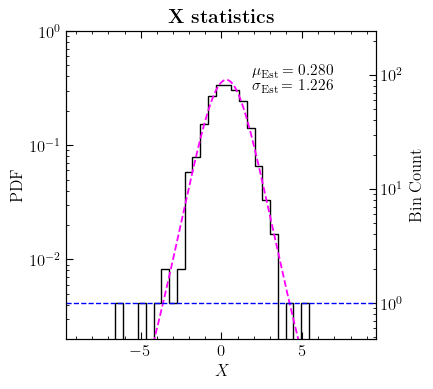

In [25]:
fig, ax = plt.subplots(figsize=(4, 4))


counts, bin_edges = np.histogram(X, bins = 25, range = (X.min(),X.max()))

# get bin width
bin_width = bin_edges[1] - bin_edges[0]
N = X.size

ax.stairs(counts/(N*bin_width), bin_edges, color='black')

# fit with student t distribution
x1 = np.linspace(-8, 8, 500)
df, loc, scale = scipy.stats.t.fit(X)
yt = scipy.stats.t.pdf(x1, df, loc, scale)

# plot t distribution
ax.plot(x1, yt, '--', lw=1.3, color='magenta')

ax.set_yscale('log')


ax.set_title(r"$\textbf{X statistics}$", fontsize=14)

# add mu and sigma value
ax.annotate(r'$\mu_{\small \rm  Est}\,$' + f'$ = {mu :.3f}$'+'\n'+r'$\sigma_{\small \rm Est}\,$' + f'$ = {sigma :.3f}$', xy = (0.6, 0.80), 
                 xycoords = 'axes fraction', fontsize = 11, ha='left',va='bottom')          

ax.set_ylim([2e-3,1e0])

# create twin axis
ax_twin = ax.twinx()

# set limits
y1, y2 = ax.get_ylim()
ax_twin.set_ylim(y1 * N * bin_width,
                 y2 * N * bin_width)

# set y scale log
ax_twin.set_yscale('log')

# show bin count 1
ax_twin.axhline(1, ls='--', lw=1, color='blue')

ax_twin.set_ylabel("Bin Count", fontsize=12)
           
ax.margins(x = 0.1, y = 0.2)

ax.set_ylabel('PDF', fontsize=12)
    
ax.set_xlabel(r'$X$', fontsize = 12)

plt.savefig(f'X_{index}.pdf', dpi = 500, bbox_inches = 'tight')
plt.show()

### $\texttt{Binned Power Spectrum Estimation}\,P(k)$

In [26]:
NBin = 5
kk, ppk, dppk = pe.binned_pk(kper, kpara, pk, sigma*dpkn,
                             NBin, fm)

# kk   = binned k values
# ppk  = binned P(k) values
# dppk = 1 sigma error in estimating binned P(k) values

print(f'{kk.shape    = }\
      \n{ppk.shape   = }\
      \n{dppk.shape  = }')

print("\n<<---------->>\n")

NBin = 7
kk, ppk, dppk = pe.binned_pk(kper, kpara, pk, sigma*dpkn,
                             NBin, fm)

# kk   = binned k values
# ppk  = binned P(k) values
# dppk = 1 sigma error in estimating binned P(k) values

print(f'{kk.shape    = }\
      \n{ppk.shape   = }\
      \n{dppk.shape  = }')

Bin count   : [ 26   3  60  96 318]

kk.shape    = (5,)      
ppk.shape   = (5,)      
dppk.shape  = (5,)

<<---------->>

Bin count   : [ 18   8  12  51  42 174 198]

kk.shape    = (7,)      
ppk.shape   = (7,)      
dppk.shape  = (7,)


### $\texttt{Dimensionless PS, Error and SNR, Upper limit}$

In [27]:
dk2, dpk2, snr, ul = pe.func_dT(kk, ppk, dppk)
print(f'{dk2.shape   = }\
      \n{dpk2.shape  = }\
      \n{snr.shape   = }\
      \n{ul.shape    = }')

dk2.shape   = (7,)      
dpk2.shape  = (7,)      
snr.shape   = (7,)      
ul.shape    = (7,)


In [28]:
mask = dk2>0
sign = np.full_like(dk2,'',dtype='str')
sign[~mask] = '-'
sign

array(['', '-', '', '', '-', '', ''], dtype='<U1')

### $\texttt{Dimensionless PS, Error and SNR, Upper limit Tabular}$

In [29]:
for i in range(len(kk)):
        print(rf'${kk[i]:.3f}$   & ${sign[i]}({np.sqrt(abs(dk2[i])):.3f})^{2}$ & $({np.sqrt(abs(dpk2[i]/2)):.3f})^{2}$   & ${snr[i]:.3f}$ & $({np.sqrt(ul[i]):.3f})^{2}$\\ \hline')

$0.161$   & $(94.740)^2$ & $(122.202)^2$   & $0.601$ & $(197.085)^2$\\ \hline
$0.212$   & $-(541.834)^2$ & $(242.003)^2$   & $-5.013$ & $(342.243)^2$\\ \hline
$0.372$   & $(950.636)^2$ & $(524.912)^2$   & $3.280$ & $(1206.140)^2$\\ \hline
$0.442$   & $(508.948)^2$ & $(494.667)^2$   & $1.059$ & $(865.112)^2$\\ \hline
$0.740$   & $-(2013.171)^2$ & $(1321.912)^2$   & $-2.319$ & $(1869.467)^2$\\ \hline
$0.963$   & $(3171.954)^2$ & $(1401.777)^2$   & $5.120$ & $(3740.488)^2$\\ \hline
$1.270$   & $(3358.771)^2$ & $(2041.543)^2$   & $2.707$ & $(4429.124)^2$\\ \hline


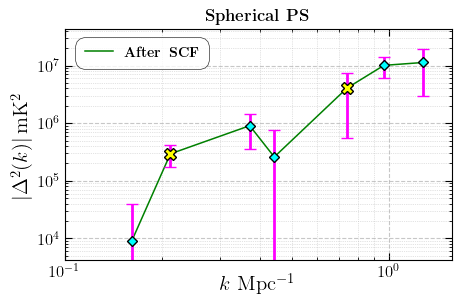

In [30]:
fig = plt.subplots(figsize = (5, 3))

# plot the graph

plt.title(r'$\textbf{Spherical PS}$', fontsize = 12)
    
# plot after scf with errorbars
plt.plot(kk, abs(dk2),'g-', lw = 1.1, label = r"\bf After  \,SCF")
plt.errorbar(kk[mask], abs(dk2)[mask], dpk2[mask],fmt = 'D' , elinewidth = 2, capsize = 4, color = 'magenta' , \
             ms = 5, mec = 'black', mfc = 'cyan')
plt.errorbar(kk[~mask], abs(dk2)[~mask], dpk2[~mask],fmt = 'X' , elinewidth = 2, capsize = 4, color = 'magenta' , \
             ms = 9, mec = 'black', mfc = 'yellow')
    
# set scale to log
plt.xscale('log')
plt.yscale('log')
# set margin 10 percent extra along both x and y
plt.margins(x = 0.1, y = 0.1)

# set x ticks and y limits
plt.xticks([1e-1,1])

# legend box style
plt.legend(
    loc = "upper left",
    bbox_to_anchor = (0.02, 0.98),
    frameon = True,          # Show legend frame
    edgecolor = "black",     # Black border
    fancybox  = True,        # Rounded corners
    fontsize  = 10)

# legend box outlier width and rounded corners
legend = plt.gca().get_legend()
# Thin border
legend.get_frame().set_linewidth(0.5)
# More rounded corners
legend.get_frame().set_boxstyle("round,rounding_size=0.8")

plt.grid(which='major', linestyle='--', linewidth=0.8, alpha=0.7) # major grid
plt.grid(which='minor', linestyle=':',  linewidth=0.5, alpha=0.7) # minor grid

# set y label $k_{\parallel}$    
plt.ylabel(r"$|\Delta^2(k)|\, {\rm mK^2}$", fontsize = 15)

# set x label $k_{\perp}$   
plt.xlabel(r'$k\,\, {\rm Mpc^{-1} }$', fontsize = 15, labelpad = -5)
   

# save the figure
plt.savefig(f'spheical_ps_{index}.pdf', dpi = 500, bbox_inches = 'tight')
plt.show()